# Problem Set 3 - Geometry and 3D Reconstruction

In [1]:
import os
import numpy as np
from scipy.ndimage import sobel
import matplotlib.pyplot as plt
import cv2
from skimage.feature import peak_local_max
from scipy.ndimage import gaussian_filter
from skimage.filters import unsharp_mask

# set numpy prints to 4 decimal points
np.set_printoptions(precision=4, suppress=True)

DATA_PATH = r'C:\Users\user\Desktop\CV Training Guy\CV_training\computer_vision\course_resources\ps_3'

In [2]:
img_a = cv2.imread(os.path.join(DATA_PATH, 'pic_a.jpg'))
img_b = cv2.imread(os.path.join(DATA_PATH, 'pic_b.jpg'))
pts_a_2d = np.loadtxt(os.path.join(DATA_PATH, 'pts2d-pic_a.txt'))
pts_b_2d = np.loadtxt(os.path.join(DATA_PATH, 'pts2d-pic_b.txt'))
pts_a_2d_norm = np.loadtxt(os.path.join(DATA_PATH, 'pts2d-norm-pic_a.txt'))
pts_3d = np.loadtxt(os.path.join(DATA_PATH, 'pts3d.txt'))
pts_3d_norm = np.loadtxt(os.path.join(DATA_PATH, 'pts3d-norm.txt'))

## 1 - Calibration
### A

In [3]:
def homogenize(p):
    return np.concatenate([p, np.ones((p.shape[0], 1))], axis=1)


def dehomogenize(p):
    return (p / p[:, -1][:, np.newaxis])[:, :-1]


def construct_A_calibration(P, p):
    assert P.shape[0] == p.shape[0], "Number of points in P and p must be the same"
    n_pts = p.shape[0]
    P = homogenize(P)
    A = np.zeros((2 * n_pts, 12))
    A[0::2, :4] = P
    A[1::2, 4:8] = P
    A[0::2, 8:12] = -p[:, 0, np.newaxis] * P
    A[1::2, 8:12] = -p[:, 1, np.newaxis] * P
    return A


def compute_projection_matrix(P, p):
    A = construct_A_calibration(P, p)
    U, S, Vt = np.linalg.svd(A, full_matrices=False)
    M = Vt[-1].reshape(3, 4)
    return M

#### $M_\text{{normA}}$

In [4]:
M_norm_a = compute_projection_matrix(pts_3d_norm, pts_a_2d_norm)
print(M_norm_a)

[[ 0.4583 -0.2947 -0.014   0.004 ]
 [-0.0509 -0.0546 -0.5411 -0.0524]
 [ 0.109   0.1783 -0.0443  0.5968]]


$\langle u , v \rangle$ - inner product of the last points

In [5]:
pts_2d_pred_norm = (M_norm_a @ homogenize(pts_3d_norm).T).T
pts_2d_pred_norm = (pts_2d_pred_norm / pts_2d_pred_norm[:, 2][:, np.newaxis])[:, :2]
pts_2d_pred_norm[-1]

array([ 0.1419, -0.4518])

The residual (the difference between the predicted and actual points)

In [6]:
residual = np.linalg.norm(pts_2d_pred_norm[-1] - pts_a_2d_norm[-1])
print(f"Residual: {residual:.4f}")

Residual: 0.0016


#### B

In [7]:
np.random.seed(42)


def rand_indices(n, k):
    return np.random.choice(n, k, replace=False)


def compute_projection_matrix_from_random_subset(P, p, k=8, k_comp=4):
    indices = rand_indices(P.shape[0], k)
    complementary_indices = np.setdiff1d(np.arange(P.shape[0]), indices)
    np.random.shuffle(complementary_indices)
    test_indices = complementary_indices[:k_comp]
    return compute_projection_matrix(P[indices], p[indices]), test_indices


def sample_trials(P, p, n_trials=10, k=8):
    residuals = []
    lowest_residual = np.inf
    best_M = None
    for _ in range(n_trials):
        M_sub, test_indices = compute_projection_matrix_from_random_subset(P, p, k)
        p_test = dehomogenize((M_sub @ homogenize(P[test_indices]).T).T)
        residual = np.linalg.norm(p_test - p[test_indices], axis=1)
        mean_residual = np.mean(residual, axis=-1)
        if mean_residual < lowest_residual:
            lowest_residual = mean_residual
            best_M = (M_sub, mean_residual)
        residuals.append(mean_residual)
    return np.array(residuals), best_M


def residual_matrix(P, p, n_trials=10, ks=(8, 12, 16)):
    res_mat = np.zeros((n_trials, len(ks)))
    lowest_residual = np.inf
    best_M_final = None
    for idx, k in enumerate(ks):
        residuals, best_M = sample_trials(P, p, n_trials=n_trials, k=k)
        res_mat[:, idx] = residuals
        if best_M[1] < lowest_residual:
            lowest_residual = best_M[1]
            best_M_final = best_M[0]
    return res_mat, best_M_final


In [8]:
res_mat, best_M = residual_matrix(pts_3d, pts_a_2d)
print(res_mat)

[[0.8014 1.2977 0.6917]
 [1.2975 2.3762 1.0789]
 [2.316  0.6057 0.9661]
 [1.0826 0.8905 1.2663]
 [2.2618 2.029  0.7495]
 [1.6712 1.2299 1.2313]
 [2.7496 1.3452 0.4815]
 [1.4346 0.9829 1.3641]
 [2.0927 0.733  0.9865]
 [1.1493 1.2897 1.7078]]


In [9]:
print(best_M)

[[-0.0031 -0.0001  0.0004  0.9789]
 [-0.0003 -0.0006  0.0028  0.2042]
 [-0.     -0.      0.      0.0013]]


In [10]:
print(f'Mean residuals for k=8: {np.mean(res_mat[:, 0]):.4f} ± {np.std(res_mat[:, 0]):.4f}')
print(f'Mean residuals for k=12: {np.mean(res_mat[:, 1]):.4f} ± {np.std(res_mat[:, 1]):.4f}')
print(f'Mean residuals for k=16: {np.mean(res_mat[:, 2]):.4f} ± {np.std(res_mat[:, 2]):.4f}')


Mean residuals for k=8: 1.6857 ± 0.6061
Mean residuals for k=12: 1.2780 ± 0.5257
Mean residuals for k=16: 1.0524 ± 0.3413


It appears that subsampling for 16 points yields the best calibration results. This suggests that using more points can lead to a more accurate estimation of the projection matrix.

In [11]:
def calculate_camera_center(M):
    Q = M[:, :3]
    m_4 = M[:, 3]
    return -np.linalg.inv(Q) @ m_4


print(calculate_camera_center(compute_projection_matrix(pts_3d_norm, pts_a_2d_norm)))

[-1.5127 -2.3517  0.2826]


In [12]:
print(calculate_camera_center(best_M))

[305.8306 304.1975  30.1358]


## 2 - Fundamental Matrix Estimation

In [13]:
def construct_A_epipolar(p1, p2):
    assert p1.shape[0] == p2.shape[0], "Number of points in p1 and p2 must be the same"
    n_pts = p1.shape[0]
    A = np.zeros((n_pts, 9))
    A[:, 0] = p2[:, 0] * p1[:, 0]
    A[:, 1] = p2[:, 0] * p1[:, 1]
    A[:, 2] = p2[:, 0]
    A[:, 3] = p2[:, 1] * p1[:, 0]
    A[:, 4] = p2[:, 1] * p1[:, 1]
    A[:, 5] = p2[:, 1]
    A[:, 6] = p1[:, 0]
    A[:, 7] = p1[:, 1]
    A[:, 8] = 1
    return A


def normalize_transform(p):
    M = np.array([[1, 0, -np.mean(p[:, 0])],
                  [0, 1, -np.mean(p[:, 1])],
                  [0, 0, 1]])
    S = np.diag(np.concatenate([1 / np.std(p, axis=0), [1]]))
    return S @ M


def compute_fundamental_matrix(p1, p2, normalize=False):
    if normalize:
        T1 = normalize_transform(p1)
        T2 = normalize_transform(p2)
        p1 = dehomogenize((T1 @ homogenize(p1).T).T)
        p2 = dehomogenize((T2 @ homogenize(p2).T).T)
    A = construct_A_epipolar(p1, p2)
    U, S, Vt = np.linalg.svd(A, full_matrices=False)
    F_hat = Vt[-1].reshape(3, 3)
    U, S, Vt = np.linalg.svd(F_hat)
    S[-1] = 0
    F = U @ np.diag(S) @ Vt
    if normalize:
        F = T2.T @ F @ T1
    return F

In [14]:
def boundary_lines(img):#, normalize_according_to=None):
    p_upper_left = homogenize(np.array([[0, 0]]))
    p_lower_left = homogenize(np.array([[0, img.shape[0]]]))
    p_upper_right = homogenize(np.array([[img.shape[1], 0]]))
    p_lower_right = homogenize(np.array([[img.shape[1], img.shape[0]]]))
    # if normalize_according_to is not None:
    #     T = normalize_transform(normalize_according_to)
    #     p_upper_left = (T @ p_upper_left.T).T
    #     p_lower_left = (T @ p_lower_left.T).T
    #     p_upper_right = (T @ p_upper_right.T).T
    #     p_lower_right = (T @ p_lower_right.T).T
    l_L = np.cross(p_upper_left, p_lower_left)
    l_R = np.cross(p_upper_right, p_lower_right)
    return l_L, l_R

In [15]:
def draw_epipolar_lines(pts_a_2d, pts_b_2d, img_a, img_b, normalize=False):
    F = compute_fundamental_matrix(pts_a_2d, pts_b_2d, normalize=normalize)
    l_b = F @ homogenize(pts_a_2d).T
    l_b = l_b.T
    l_a = F.T @ homogenize(pts_b_2d).T
    l_a = l_a.T

    l_L_a, l_R_a = boundary_lines(img_a)#, normalize_according_to=pts_a_2d if normalize else None)
    l_L_b, l_R_b = boundary_lines(img_b)#, normalize_according_to=pts_b_2d if normalize else None)

    p_a_L = np.cross(l_a, l_L_a)
    p_a_R = np.cross(l_a, l_R_a)
    p_b_L = np.cross(l_b, l_L_b)
    p_b_R = np.cross(l_b, l_R_b)

    # if normalize:
    #     T_a_inv = np.linalg.inv(normalize_transform(pts_a_2d))
    #     T_b_inv = np.linalg.inv(normalize_transform(pts_b_2d))
    #     p_a_L = (T_a_inv @ p_a_L.T).T
    #     p_a_R = (T_a_inv @ p_a_R.T).T
    #     p_b_L = (T_b_inv @ p_b_L.T).T
    #     p_b_R = (T_b_inv @ p_b_R.T).T

    p_a_L = (p_a_L / p_a_L[:, -1][:, np.newaxis])[:, :-1]
    p_a_R = (p_a_R / p_a_R[:, -1][:, np.newaxis])[:, :-1]
    p_b_L = (p_b_L / p_b_L[:, -1][:, np.newaxis])[:, :-1]
    p_b_R = (p_b_R / p_b_R[:, -1][:, np.newaxis])[:, :-1]

    img_a_copy = img_a.copy()
    img_b_copy = img_b.copy()

    fig, axes = plt.subplots(1, 2, figsize=(20, 8))
    for p_L, p_R in zip(p_a_L, p_a_R):
        print(f"Epipolar line in image A: {p_L}, {p_R}")
        cv2.line(img_a, tuple(p_L.astype(int)), tuple(p_R.astype(int)), (255, 0, 0), 1)
    axes[0].set_title('Epipolar Lines in Image A')
    axes[0].imshow(cv2.cvtColor(img_a_copy, cv2.COLOR_BGR2RGB))
    axes[0].axis('off')
    for p_L, p_R in zip(p_b_L, p_b_R):
        cv2.line(img_b, tuple(p_L.astype(int)), tuple(p_R.astype(int)), (255, 0, 0), 1)
    axes[1].set_title('Epipolar Lines in Image B')
    axes[1].imshow(cv2.cvtColor(img_b_copy, cv2.COLOR_BGR2RGB))
    axes[1].axis('off')
    plt.show()

Epipolar line in image A: [  0.     182.8525], [1072.      225.1609]
Epipolar line in image A: [  0.     201.6233], [1072.      254.1724]
Epipolar line in image A: [  0.     186.6296], [1072.      230.9987]
Epipolar line in image A: [  0.     275.0291], [1072.      367.6256]
Epipolar line in image A: [  0.     249.6332], [1072.      328.3748]
Epipolar line in image A: [  0.     124.7466], [1072.      135.3547]
Epipolar line in image A: [  0.     498.4165], [1072.      712.8849]
Epipolar line in image A: [  0.     194.8505], [1072.      243.7045]
Epipolar line in image A: [  0.    303.172], [1072.      411.1223]
Epipolar line in image A: [  0.     406.5887], [1072.      570.9593]
Epipolar line in image A: [  0.     391.5126], [1072.      547.6582]
Epipolar line in image A: [  0.     349.9201], [1072.      483.3745]
Epipolar line in image A: [  0.     299.5592], [1072.      405.5384]
Epipolar line in image A: [  0.     293.7951], [1072.      396.6297]
Epipolar line in image A: [  0.     

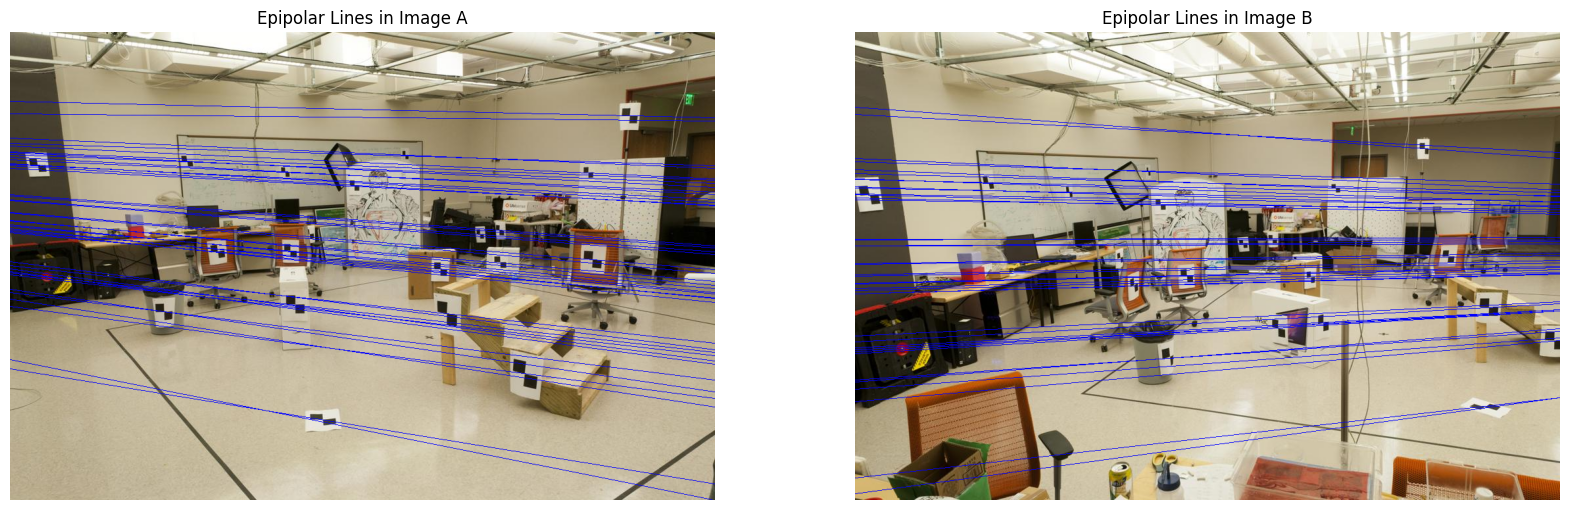

In [19]:
draw_epipolar_lines(pts_a_2d, pts_b_2d, img_a, img_b, normalize=False)

Epipolar line in image A: [  0.     173.7693], [1072.      223.6733]
Epipolar line in image A: [  0.     200.2529], [1072.      259.9558]
Epipolar line in image A: [  0.     183.0874], [1072.      236.4391]
Epipolar line in image A: [  0.     274.3091], [1072.      361.4126]
Epipolar line in image A: [  0.     247.9168], [1072.      325.2553]
Epipolar line in image A: [  0.     105.6947], [1072.      130.4113]
Epipolar line in image A: [  0.     512.3196], [1072.      687.4866]
Epipolar line in image A: [  0.     190.9369], [1072.      247.1929]
Epipolar line in image A: [  0.     305.4276], [1072.      404.0449]
Epipolar line in image A: [  0.     417.7227], [1072.     557.889]
Epipolar line in image A: [  0.     396.8607], [1072.      529.3082]
Epipolar line in image A: [  0.    355.911], [1072.      473.2071]
Epipolar line in image A: [  0.     301.4023], [1072.      398.5303]
Epipolar line in image A: [  0.     295.5045], [1072.      390.4503]
Epipolar line in image A: [  0.     36

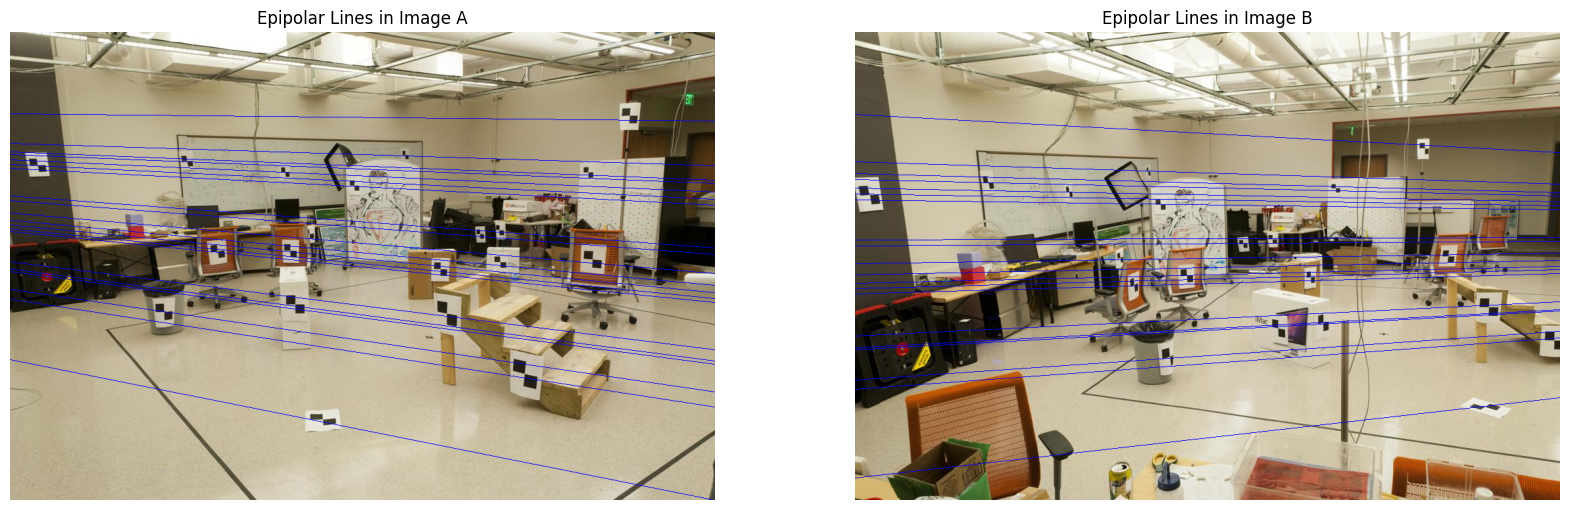

In [17]:
draw_epipolar_lines(pts_a_2d, pts_b_2d, img_a, img_b, normalize=True)

In [ ]:
a = np.array([[1,2,3]])
b = np.array([4,5,6])
